# Notebook 17 - Parametric calibration and one-model-day-ahead forecasting

## Exercise 2: event-unaware parametric background

This notebook calibrates the constant-coefficient Gaussian empirical system frozen in Notebook 16 and evaluates genuine chronological out-of-sample forecasts. It does not repeat BIC or Granger-causality selection, use events as regressors, remove event days, construct an eventless series, estimate event weights, implement Equation (5), or begin Exercise 3.

## 1. Frozen upstream contract

The three empirical states are \(Q_t=r_t^2\), \(R_t=252\,RV_t^{\mathrm{within}}\), and \(I_t=(q_t/100)^2\). The primary realised state is annualised exactly once here; implied variance is already annualised. The observed lagged overnight/1D ATM state is an empirical predictor, not a claim of equality with the theoretical forward-implied-variance object.

Notebook 16 is authoritative: the realised equation has \(n=1\), the implied equation has \(m=16\), and all four cross-variable blocks are retained. Equation (1) retains a constant mean \(\mu\) and no AR term. This is an event-unaware parametric background, not an eventless calibration.

In [1]:
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 100)
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data' / 'processed').exists())
PROCESSED = PROJECT_ROOT / 'Data' / 'processed'
PANEL_PATH = PROCESSED / 'usdjpy_daily_model_panel.csv'
MODEL_SPEC_PATH = PROCESSED / '16_model_specification.csv'
TARGET_SUMMARY_PATH = PROCESSED / '16_target_model_summary.csv'
SYSTEM_SPEC_PATH = PROCESSED / '16_system_specification.csv'
RUN_ID = pd.Timestamp.now(tz='UTC').isoformat()
MAX_LAG = 16
POSITIVE_FLOOR = 1e-12
ALPHA = 0.05
assert PANEL_PATH.exists() and MODEL_SPEC_PATH.exists() and TARGET_SUMMARY_PATH.exists() and SYSTEM_SPEC_PATH.exists()
print(f'Project root: {PROJECT_ROOT}')
print(f'Notebook 17 RUN_ID: {RUN_ID}')
print(f'Positive floor for QLIKE/square-root/log-score only: {POSITIVE_FLOOR:g}')

Project root: C:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do
Notebook 17 RUN_ID: 2026-08-11T02:49:01.489250+00:00
Positive floor for QLIKE/square-root/log-score only: 1e-12


## 2. Load the canonical panel and validate the frozen structure

The chronological 60/20/20 split is reconstructed exactly as in Notebook 16, before eligibility filtering. Each conditional-mean equation is estimated on its own target-specific lag-complete sample. Forecast benchmarks use common target dates within a target/split, so an easier benchmark cannot benefit from a larger evaluation sample.

In [2]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
model_spec = pd.read_csv(MODEL_SPEC_PATH)
target_summary = pd.read_csv(TARGET_SUMMARY_PATH)
system_spec = pd.read_csv(SYSTEM_SPEC_PATH)

required_panel = {'model_day', 'within_session_log_return', 'rv_within', 'iv_ann_var', 'rv_eligible'}
assert required_panel.issubset(panel.columns)
assert panel['model_day'].is_monotonic_increasing and panel['model_day'].is_unique
assert model_spec['RUN_ID'].nunique() == 1 and target_summary['RUN_ID'].nunique() == 1
selected_orders = target_summary.set_index('target')['selected_history_order'].astype(int).to_dict()
assert selected_orders == {'realised_variance_ann_252': 1, 'implied_variance_ann': 16}, selected_orders
required_edges = {
    ('squared_return', 'realised_variance_ann_252'),
    ('implied_variance_ann', 'realised_variance_ann_252'),
    ('squared_return', 'implied_variance_ann'),
    ('realised_variance_ann_252', 'implied_variance_ann'),
}
retained_edges = set(
    model_spec.loc[model_spec['retained_from_train_validation'].astype(bool), ['source', 'target']]
    .itertuples(index=False, name=None)
)
assert retained_edges == required_edges, retained_edges
assert set(system_spec['equation']) == {'spot_return', 'realised_variance', 'implied_variance'}

panel['r'] = pd.to_numeric(panel['within_session_log_return'], errors='coerce')
panel['Q'] = panel['r'].pow(2)
panel['R'] = 252.0 * pd.to_numeric(panel['rv_within'], errors='coerce')
panel['I'] = pd.to_numeric(panel['iv_ann_var'], errors='coerce')
assert np.allclose(panel.loc[panel['rv_within'].notna(), 'R'], 252.0 * panel.loc[panel['rv_within'].notna(), 'rv_within'])
assert np.allclose(panel.loc[panel['r'].notna(), 'Q'], panel.loc[panel['r'].notna(), 'r'].pow(2))
assert np.allclose(panel.loc[panel['I'].notna(), 'I'], panel.loc[panel['I'].notna(), 'iv_ann_var'])

N = len(panel)
train_end, validation_end = math.floor(0.60 * N), math.floor(0.80 * N)
panel['sample_split'] = np.select(
    [panel.index < train_end, panel.index < validation_end],
    ['train', 'validation'],
    default='test',
)
assert panel.loc[panel['sample_split'].eq('train'), 'model_day'].max() < panel.loc[panel['sample_split'].eq('validation'), 'model_day'].min()
assert panel.loc[panel['sample_split'].eq('validation'), 'model_day'].max() < panel.loc[panel['sample_split'].eq('test'), 'model_day'].min()
for state in ['Q', 'R', 'I']:
    for lag in range(1, MAX_LAG + 1):
        panel[f'{state}_lag{lag}'] = panel[state].shift(lag)
        assert panel.loc[lag:, f'{state}_lag{lag}'].reset_index(drop=True).equals(panel.loc[:N-lag-1, state].reset_index(drop=True))
panel['structure_eligible'] = panel['rv_eligible'].fillna(False).astype(bool) & np.isfinite(panel[['Q', 'R', 'I']]).all(axis=1)
display(pd.DataFrame({
    'rows': panel.groupby('sample_split', sort=False).size(),
    'structure_eligible_rows': panel.loc[panel['structure_eligible']].groupby('sample_split', sort=False).size(),
}))
print('Frozen upstream RUN_ID:', model_spec['RUN_ID'].iloc[0])

,rows,structure_eligible_rows
sample_split,,
train,3626,3053
validation,1209,1195
test,1209,1195


Frozen upstream RUN_ID: 2026-08-11T02:29:19.042796+00:00


## 3. Pre-specified models and conditional-Gaussian calibration

Conditional Gaussian maximum likelihood is used. With a linear conditional mean and a constant Gaussian innovation scale, the conditional-mean MLE is OLS; the residual innovation variance is estimated after fitting. Individual coefficient significance is reported but never used to alter the frozen full model.

For the return observation equation, \(\widehat\mu\) is the sample mean of eligible signed returns in the calibration sample. In-sample diagnostics use observed \(R_t\); out-of-sample return distributions instead use \(\widehat R_{t\mid t-1}\).

In [3]:
R_MODELS = {
    'R0_PERSISTENCE': {'target': 'R', 'features': None, 'persistence_feature': 'R_lag1'},
    'R1_AR': {'target': 'R', 'features': ['R_lag1']},
    'R2_AR_Q': {'target': 'R', 'features': ['Q_lag1', 'R_lag1']},
    'R3_AR_I': {'target': 'R', 'features': ['R_lag1', 'I_lag1']},
    'R4_FULL': {'target': 'R', 'features': ['Q_lag1', 'R_lag1', 'I_lag1']},
}
I_LAGS = [f'I_lag{j}' for j in range(1, 17)]
Q_LAGS = [f'Q_lag{j}' for j in range(1, 17)]
R_LAGS = [f'R_lag{j}' for j in range(1, 17)]
I_MODELS = {
    'I0_PERSISTENCE': {'target': 'I', 'features': None, 'persistence_feature': 'I_lag1'},
    'I1_AR16': {'target': 'I', 'features': I_LAGS},
    'I2_AR16_Q': {'target': 'I', 'features': I_LAGS + Q_LAGS},
    'I3_AR16_R': {'target': 'I', 'features': I_LAGS + R_LAGS},
    'I4_FULL': {'target': 'I', 'features': I_LAGS + Q_LAGS + R_LAGS},
}
MODEL_CONFIGS = {**R_MODELS, **I_MODELS}
COMMON_FEATURES = {'R': R_MODELS['R4_FULL']['features'], 'I': I_MODELS['I4_FULL']['features']}

def finite_rows(frame, target, features, allowed_splits=None, before_date=None):
    use = frame
    if allowed_splits is not None:
        use = use.loc[use['sample_split'].isin(allowed_splits)]
    if before_date is not None:
        use = use.loc[use['model_day'].lt(before_date)]
    cols = [target] + list(features)
    mask = np.isfinite(use[cols]).all(axis=1)
    return use.loc[mask, ['model_day', 'sample_split', 'r', target] + list(features)].copy()

def fit_ols(frame, model_name, allowed_splits=None, before_date=None):
    cfg = MODEL_CONFIGS[model_name]
    if cfg['features'] is None:
        return {'model_name': model_name, 'target': cfg['target'], 'features': [], 'fit': None, 'sample': pd.DataFrame()}
    sample = finite_rows(frame, cfg['target'], cfg['features'], allowed_splits, before_date)
    y = sample[cfg['target']].to_numpy(float)
    X = sm.add_constant(sample[cfg['features']].to_numpy(float), has_constant='add')
    fit = sm.OLS(y, X).fit()
    return {'model_name': model_name, 'target': cfg['target'], 'features': cfg['features'], 'fit': fit, 'sample': sample}

def common_evaluation_rows(frame, target, split):
    rows = finite_rows(frame, target, COMMON_FEATURES[target], [split])
    assert rows['model_day'].is_unique
    return rows

def raw_forecast(fitted, eval_rows):
    cfg = MODEL_CONFIGS[fitted['model_name']]
    if cfg['features'] is None:
        return eval_rows[cfg['persistence_feature']].to_numpy(float)
    X = sm.add_constant(eval_rows[cfg['features']].to_numpy(float), has_constant='add')
    return np.asarray(fitted['fit'].predict(X), dtype=float)

def coefficient_table(fitted, calibration_stage):
    if fitted['fit'] is None:
        return pd.DataFrame()
    result = fitted['fit']
    names = ['const'] + fitted['features']
    table = pd.DataFrame({
        'coefficient': names, 'estimate': result.params, 'std_error': result.bse,
        't_stat': result.tvalues, 'p_value': result.pvalues,
    })
    table['model_name'] = fitted['model_name']
    table['target'] = fitted['target']
    table['calibration_stage'] = calibration_stage
    table['n_observations'] = len(fitted['sample'])
    table['sample_start'] = fitted['sample']['model_day'].min()
    table['sample_end'] = fitted['sample']['model_day'].max()
    table['residual_sd'] = math.sqrt(result.mse_resid)
    table['adjusted_R2'] = result.rsquared_adj
    table['condition_number'] = result.condition_number
    table['coefficient_group'] = np.select(
        [table['coefficient'].eq('const'), table['coefficient'].str.startswith('Q_'),
         table['coefficient'].str.startswith('R_'), table['coefficient'].str.startswith('I_')],
        ['intercept', 'Q_lags', 'R_lags', 'I_lags'],
        default='other',
    )
    return table

def innovation_row(fitted, calibration_stage):
    if fitted['fit'] is None:
        return None
    sd = math.sqrt(fitted['fit'].mse_resid)
    scale = math.sqrt(252.0) * sd
    return {
        'model_name': fitted['model_name'], 'target': fitted['target'],
        'calibration_stage': calibration_stage, 'residual_innovation_sd': sd,
        'scale_under_delta_t_1_over_252': scale, 'delta_t': 1/252,
        'n_observations': len(fitted['sample']),
        'interpretation': 'scale mapping conditional on Delta t=1/252; residual does not separately identify latent scale and shock',
    }

def make_forecast_records(fits, split, scheme):
    records = []
    for target, names in [('R', list(R_MODELS)), ('I', list(I_MODELS))]:
        evaluation = common_evaluation_rows(panel, target, split)
        baseline_dates = evaluation['model_day'].to_numpy()
        for name in names:
            raw = raw_forecast(fits[name], evaluation)
            assert len(raw) == len(evaluation) and np.array_equal(evaluation['model_day'].to_numpy(), baseline_dates)
            records.append(pd.DataFrame({
                'model_day': evaluation['model_day'].to_numpy(), 'sample_split': split,
                'forecast_scheme': scheme, 'model_name': name, 'target': target,
                'actual': evaluation[target].to_numpy(float), 'raw_forecast': raw,
            }))
    out = pd.concat(records, ignore_index=True)
    out['positive_forecast'] = np.maximum(out['raw_forecast'], POSITIVE_FLOOR)
    out['forecast_error'] = out['actual'] - out['raw_forecast']
    out['nonpositive_forecast'] = out['raw_forecast'].le(0)
    assert out.groupby(['forecast_scheme', 'target', 'model_name'])['model_day'].nunique().eq(out.groupby(['forecast_scheme', 'target', 'model_name']).size()).all()
    return out

def metric_table(records):
    rows = []
    for (scheme, split, target), group in records.groupby(['forecast_scheme', 'sample_split', 'target'], sort=False):
        persist = group.loc[group['model_name'].str.endswith('PERSISTENCE'), ['model_day', 'raw_forecast']].rename(columns={'raw_forecast':'persistence_forecast'})
        for model_name, model in group.groupby('model_name', sort=False):
            z = model.merge(persist, on='model_day', validate='one_to_one')
            assert len(z) == len(persist)
            err = z['actual'] - z['raw_forecast']
            persistence_err = z['actual'] - z['persistence_forecast']
            rows.append({
                'forecast_scheme': scheme, 'sample_split': split, 'target': target, 'model_name': model_name,
                'n_forecasts': len(z), 'MAE': err.abs().mean(), 'RMSE': np.sqrt(np.mean(err.pow(2))),
                'QLIKE': (np.log(z['positive_forecast']) + z['actual'] / z['positive_forecast']).mean(),
                'OOS_R2_vs_persistence': 1 - err.pow(2).sum() / persistence_err.pow(2).sum(),
                'nonpositive_count': int(z['nonpositive_forecast'].sum()),
                'nonpositive_fraction': float(z['nonpositive_forecast'].mean()),
                'minimum_raw_forecast': float(z['raw_forecast'].min()),
            })
    return pd.DataFrame(rows)

assert selected_orders['realised_variance_ann_252'] == 1 and selected_orders['implied_variance_ann'] == 16
assert set(R_MODELS['R4_FULL']['features']) == {'Q_lag1', 'R_lag1', 'I_lag1'}
assert len(I_MODELS['I4_FULL']['features']) == 48

## 4. Training calibration and validation forecasts

Stage A estimates the pre-specified models using training data only, then forecasts validation. Validation is used to check the frozen forecasting protocol and to describe performance; it is not used to modify orders, blocks, transformations, or targets.

In [4]:
train_fits = {name: fit_ols(panel, name, ['train']) for name in MODEL_CONFIGS}
train_mu_sample = panel.loc[panel['sample_split'].eq('train') & np.isfinite(panel['r']), ['model_day', 'r']]
assert len(train_mu_sample) > 0
mu_train = train_mu_sample['r'].mean()
train_coefficients = pd.concat([coefficient_table(fit, 'train') for fit in train_fits.values() if fit['fit'] is not None], ignore_index=True)
train_innovation_rows = [innovation_row(train_fits[name], 'train') for name in ['R4_FULL', 'I4_FULL']]
train_innovation_rows = [x for x in train_innovation_rows if x is not None]
validation_forecasts = make_forecast_records(train_fits, 'validation', 'fixed_train')
validation_metrics = metric_table(validation_forecasts)
display(train_coefficients.loc[train_coefficients['model_name'].isin(['R4_FULL', 'I4_FULL'])])
display(validation_metrics)

,coefficient,estimate,std_error,t_stat,p_value,model_name,target,calibration_stage,n_observations,sample_start,sample_end,residual_sd,adjusted_R2,condition_number,coefficient_group
8,const,0.002974,0.000365,8.148302,5.357976e-16,R4_FULL,R,train,3005,2003-05-07,2017-03-27,0.016101,0.325639,12136.385634,intercept
9,Q_lag1,9.057614,3.563823,2.541544,1.108631e-02,R4_FULL,R,train,3005,2003-05-07,2017-03-27,0.016101,0.325639,12136.385634,Q_lags
10,R_lag1,0.082522,0.021398,3.856541,1.174183e-04,R4_FULL,R,train,3005,2003-05-07,2017-03-27,0.016101,0.325639,12136.385634,R_lags
11,I_lag1,0.407520,0.014612,27.889884,2.070935e-152,R4_FULL,R,train,3005,2003-05-07,2017-03-27,0.016101,0.325639,12136.385634,I_lags
95,const,-0.000050,0.000538,-0.092615,9.262185e-01,I4_FULL,I,train,2099,2006-01-26,2017-03-27,0.015844,0.638316,15533.845925,intercept
96,I_lag1,0.353323,0.022704,15.562454,1.054676e-51,I4_FULL,I,train,2099,2006-01-26,2017-03-27,0.015844,0.638316,15533.845925,I_lags
97,I_lag2,0.154296,0.026409,5.842457,5.968253e-09,I4_FULL,I,train,2099,2006-01-26,2017-03-27,0.015844,0.638316,15533.845925,I_lags
98,I_lag3,0.040638,0.026818,1.515335,1.298419e-01,I4_FULL,I,train,2099,2006-01-26,2017-03-27,0.015844,0.638316,15533.845925,I_lags
99,I_lag4,-0.030062,0.026571,-1.131374,2.580300e-01,I4_FULL,I,train,2099,2006-01-26,2017-03-27,0.015844,0.638316,15533.845925,I_lags
100,I_lag5,-0.006056,0.026538,-0.228211,8.195049e-01,I4_FULL,I,train,2099,2006-01-26,2017-03-27,0.015844,0.638316,15533.845925,I_lags


,forecast_scheme,sample_split,target,model_name,n_forecasts,MAE,RMSE,QLIKE,OOS_R2_vs_persistence,nonpositive_count,nonpositive_fraction,minimum_raw_forecast
0,fixed_train,validation,R,R0_PERSISTENCE,1181,0.002889,0.007810,-4.387778e+00,0.000000,0,0.000000,0.000072
1,fixed_train,validation,R,R1_AR,1181,0.005390,0.007954,-4.302870e+00,-0.037092,0,0.000000,0.006764
2,fixed_train,validation,R,R2_AR_Q,1181,0.005336,0.007891,-4.307119e+00,-0.020879,0,0.000000,0.006705
3,fixed_train,validation,R,R3_AR_I,1181,0.002996,0.006479,-4.519570e+00,0.311754,0,0.000000,0.003188
4,fixed_train,validation,R,R4_FULL,1181,0.002978,0.006452,-4.521272e+00,0.317485,0,0.000000,0.003174
5,fixed_train,validation,I,I0_PERSISTENCE,1055,0.002570,0.006200,-4.293502e+00,0.000000,0,0.000000,0.000443
6,fixed_train,validation,I,I1_AR16,1055,0.002443,0.005586,2.294441e+06,0.188196,1,0.000948,-0.002207
7,fixed_train,validation,I,I2_AR16_Q,1055,0.002613,0.005955,8.015845e+07,0.077430,22,0.020853,-0.012501
8,fixed_train,validation,I,I3_AR16_R,1055,0.002185,0.005882,1.440233e+07,0.099775,6,0.005687,-0.005009
9,fixed_train,validation,I,I4_FULL,1055,0.002602,0.006062,7.724589e+07,0.044044,22,0.020853,-0.011222


## 5. Final calibration and primary fixed-coefficient test forecasts

Stage B combines training and validation, refits the unchanged specifications once, then holds coefficients fixed over the untouched test interval. This is the primary Exercise 2 forecasting result.

In [5]:
final_fits = {name: fit_ols(panel, name, ['train', 'validation']) for name in MODEL_CONFIGS}
final_mu_sample = panel.loc[panel['sample_split'].isin(['train', 'validation']) & np.isfinite(panel['r']), ['model_day', 'r']]
mu_final = final_mu_sample['r'].mean()
final_coefficients = pd.concat([coefficient_table(fit, 'train_validation') for fit in final_fits.values() if fit['fit'] is not None], ignore_index=True)
innovation_scales = pd.DataFrame([innovation_row(final_fits[name], 'train_validation') for name in ['R4_FULL', 'I4_FULL']])
test_forecasts = make_forecast_records(final_fits, 'test', 'fixed_train_validation')
test_metrics = metric_table(test_forecasts)
display(final_coefficients.loc[final_coefficients['model_name'].eq('R4_FULL')])
display(final_coefficients.loc[final_coefficients['model_name'].eq('I4_FULL')].sort_values(['coefficient_group', 'coefficient']))
display(innovation_scales)
display(test_metrics)

,coefficient,estimate,std_error,t_stat,p_value,model_name,target,calibration_stage,n_observations,sample_start,sample_end,residual_sd,adjusted_R2,condition_number,coefficient_group
8,const,0.002489,0.000262,9.514082,3.002930e-21,R4_FULL,R,train_validation,4186,2003-05-07,2021-11-12,0.014058,0.3475,13562.232565,intercept
9,Q_lag1,9.577651,2.946310,3.250728,1.160222e-03,R4_FULL,R,train_validation,4186,2003-05-07,2021-11-12,0.014058,0.3475,13562.232565,Q_lags
10,R_lag1,0.087319,0.018070,4.832381,1.397459e-06,R4_FULL,R,train_validation,4186,2003-05-07,2021-11-12,0.014058,0.3475,13562.232565,R_lags
11,I_lag1,0.413918,0.012361,33.486473,5.112541e-218,R4_FULL,R,train_validation,4186,2003-05-07,2021-11-12,0.014058,0.3475,13562.232565,I_lags


,coefficient,estimate,std_error,t_stat,p_value,model_name,target,calibration_stage,n_observations,sample_start,sample_end,residual_sd,adjusted_R2,condition_number,coefficient_group
96,I_lag1,0.358465,0.018559,19.314750,1.378549e-78,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
105,I_lag10,0.343361,0.025035,13.715053,1.314182e-41,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
106,I_lag11,0.100996,0.026066,3.874588,1.090116e-04,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
107,I_lag12,-0.058132,0.025620,-2.269024,2.333517e-02,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
108,I_lag13,0.105606,0.025662,4.115326,3.966878e-05,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
109,I_lag14,-0.055570,0.025183,-2.206688,2.740877e-02,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
110,I_lag15,0.256951,0.024648,10.424850,4.920195e-25,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
111,I_lag16,-0.262115,0.024282,-10.794728,1.078838e-26,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
97,I_lag2,0.157251,0.021671,7.256124,5.008721e-13,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags
98,I_lag3,0.044400,0.021986,2.019464,4.352476e-02,I4_FULL,I,train_validation,3154,2006-01-26,2021-11-08,0.013308,0.657796,17935.868022,I_lags


,model_name,target,calibration_stage,residual_innovation_sd,scale_under_delta_t_1_over_252,delta_t,n_observations,interpretation
0,R4_FULL,R,train_validation,0.014058,0.223156,0.003968,4186,scale mapping conditional on Delta t=1/252; re...
1,I4_FULL,I,train_validation,0.013308,0.211264,0.003968,3154,scale mapping conditional on Delta t=1/252; re...


,forecast_scheme,sample_split,target,model_name,n_forecasts,MAE,RMSE,QLIKE,OOS_R2_vs_persistence,nonpositive_count,nonpositive_fraction,minimum_raw_forecast
0,fixed_train_validation,test,R,R0_PERSISTENCE,1182,0.007978,0.021240,-3.382092e+00,0.000000,0,0.000000,0.000208
1,fixed_train_validation,test,R,R1_AR,1182,0.006837,0.016858,-3.712840e+00,0.370073,0,0.000000,0.005558
2,fixed_train_validation,test,R,R2_AR_Q,1182,0.006851,0.016824,-3.716579e+00,0.372577,0,0.000000,0.005498
3,fixed_train_validation,test,R,R3_AR_I,1182,0.005547,0.015011,-3.856390e+00,0.500535,0,0.000000,0.002782
4,fixed_train_validation,test,R,R4_FULL,1182,0.005546,0.014989,-3.859802e+00,0.502021,0,0.000000,0.002756
5,fixed_train_validation,test,I,I0_PERSISTENCE,1031,0.008110,0.019483,-3.360512e+00,0.000000,0,0.000000,0.000555
6,fixed_train_validation,test,I,I1_AR16,1031,0.006773,0.015376,6.559175e+07,0.377208,10,0.009699,-0.021722
7,fixed_train_validation,test,I,I2_AR16_Q,1031,0.007815,0.016730,3.159313e+08,0.262671,34,0.032978,-0.044119
8,fixed_train_validation,test,I,I3_AR16_R,1031,0.007270,0.016137,1.859164e+08,0.313972,26,0.025218,-0.030098
9,fixed_train_validation,test,I,I4_FULL,1031,0.007800,0.016776,3.084418e+08,0.258547,36,0.034918,-0.039712


## 6. Equation (1) return-distribution forecasting diagnostic

The observed contemporaneous-\(R_t\) return diagnostic is not a forecast. The relevant out-of-sample distribution is instead \(r_t\mid\mathcal F_{t-1}\sim N(\widehat\mu,\widehat R_{t\mid t-1}/252)\), using the full realised-variance forecast. The positive floor is used only for square roots and Gaussian scoring, while raw variance forecasts remain separately audited.

In [6]:
def return_distribution_diagnostics(forecasts, mu_by_scheme):
    full_r = forecasts.loc[forecasts['model_name'].eq('R4_FULL')].copy()
    joined = full_r.merge(panel[['model_day', 'r']], on='model_day', how='left', validate='one_to_one')
    joined['mu_hat'] = joined['forecast_scheme'].map(mu_by_scheme)
    joined['forecast_variance'] = joined['positive_forecast'] / 252.0
    joined['z_forecast'] = (joined['r'] - joined['mu_hat']) / np.sqrt(joined['forecast_variance'])
    joined['nll'] = 0.5 * (np.log(2 * np.pi * joined['forecast_variance']) + (joined['r'] - joined['mu_hat']).pow(2) / joined['forecast_variance'])
    rows = []
    for (scheme, split), g in joined.groupby(['forecast_scheme', 'sample_split'], sort=False):
        z = g['z_forecast'].dropna()
        lb_z = acorr_ljungbox(z, lags=[5, 10], return_df=True)
        lb_z2 = acorr_ljungbox(z.pow(2), lags=[5, 10], return_df=True)
        for nominal in [0.68, 0.95]:
            critical = stats.norm.ppf((1 + nominal) / 2)
            rows.append({
                'forecast_scheme': scheme, 'sample_split': split, 'n_observations': len(z),
                'mean_z': z.mean(), 'std_z': z.std(ddof=1), 'variance_z': z.var(ddof=1),
                'skewness_z': stats.skew(z, bias=False), 'excess_kurtosis_z': stats.kurtosis(z, fisher=True, bias=False),
                'Ljung_Box_z_p_lag5': lb_z.loc[5, 'lb_pvalue'], 'Ljung_Box_z_p_lag10': lb_z.loc[10, 'lb_pvalue'],
                'Ljung_Box_z2_p_lag5': lb_z2.loc[5, 'lb_pvalue'], 'Ljung_Box_z2_p_lag10': lb_z2.loc[10, 'lb_pvalue'],
                'interval_nominal_coverage': nominal, 'interval_empirical_coverage': float((z.abs() <= critical).mean()),
                'mean_NLL': g['nll'].mean(), 'outside_interval_count': int((z.abs() > critical).sum()),
                'outside_interval_fraction': float((z.abs() > critical).mean()),
            })
    return joined, pd.DataFrame(rows)

return_forecasts, return_diagnostics = return_distribution_diagnostics(
    pd.concat([validation_forecasts, test_forecasts], ignore_index=True),
    {'fixed_train': mu_train, 'fixed_train_validation': mu_final},
)
display(return_diagnostics)

,forecast_scheme,sample_split,n_observations,mean_z,std_z,variance_z,skewness_z,excess_kurtosis_z,Ljung_Box_z_p_lag5,Ljung_Box_z_p_lag10,Ljung_Box_z2_p_lag5,Ljung_Box_z2_p_lag10,interval_nominal_coverage,interval_empirical_coverage,mean_NLL,outside_interval_count,outside_interval_fraction
0,fixed_train,validation,1181,0.001056,0.848752,0.720379,0.012033,1.479667,0.288494,0.600144,0.565979,0.231482,0.68,0.782388,-4.108424,257,0.217612
1,fixed_train,validation,1181,0.001056,0.848752,0.720379,0.012033,1.479667,0.288494,0.600144,0.565979,0.231482,0.95,0.968671,-4.108424,37,0.031329
2,fixed_train_validation,test,1182,0.071196,1.038826,1.079159,-0.437083,1.372400,0.660373,0.718751,0.069564,0.190367,0.68,0.689509,-3.754618,367,0.310491
3,fixed_train_validation,test,1182,0.071196,1.038826,1.079159,-0.437083,1.372400,0.660373,0.718751,0.069564,0.190367,0.95,0.939086,-3.754618,72,0.060914


## 7. Secondary expanding-window sensitivity and temporal performance

The expanding-window exercise refits only the already frozen full \(Q/R/I\) models using observations strictly before each test target. It is a stability sensitivity, not a tuning procedure; the fixed train-plus-validation test remains primary.

In [7]:
def expanding_full_forecasts(target, full_model, persistence_model):
    evaluation = common_evaluation_rows(panel, target, 'test')
    records = []
    for row in evaluation.itertuples(index=False):
        date = row.model_day
        fitted = fit_ols(panel, full_model, before_date=date)
        assert fitted['sample']['model_day'].max() < date
        row_df = evaluation.loc[evaluation['model_day'].eq(date)]
        full_raw = raw_forecast(fitted, row_df)[0]
        persistence_raw = row_df[MODEL_CONFIGS[persistence_model]['persistence_feature']].iloc[0]
        for model_name, raw in [(persistence_model, persistence_raw), (full_model, full_raw)]:
            records.append({
                'model_day': date, 'sample_split': 'test', 'forecast_scheme': 'expanding_window',
                'model_name': model_name, 'target': target, 'actual': row_df[target].iloc[0],
                'raw_forecast': raw,
            })
    out = pd.DataFrame(records)
    out['positive_forecast'] = np.maximum(out['raw_forecast'], POSITIVE_FLOOR)
    out['forecast_error'] = out['actual'] - out['raw_forecast']
    out['nonpositive_forecast'] = out['raw_forecast'].le(0)
    return out

expanding_forecasts = pd.concat([
    expanding_full_forecasts('R', 'R4_FULL', 'R0_PERSISTENCE'),
    expanding_full_forecasts('I', 'I4_FULL', 'I0_PERSISTENCE'),
], ignore_index=True)
expanding_metrics = metric_table(expanding_forecasts)
all_forecasts = pd.concat([validation_forecasts, test_forecasts, expanding_forecasts], ignore_index=True)
all_metrics = pd.concat([validation_metrics, test_metrics, expanding_metrics], ignore_index=True)
nonpositive_audit = (all_forecasts.groupby(['forecast_scheme', 'sample_split', 'target', 'model_name'], as_index=False)
    .agg(n_forecasts=('raw_forecast', 'size'), nonpositive_count=('nonpositive_forecast', 'sum'),
         nonpositive_fraction=('nonpositive_forecast', 'mean'), minimum_raw_forecast=('raw_forecast', 'min')))
fixed_full_test = test_forecasts.loc[test_forecasts['model_name'].isin(['R4_FULL', 'I4_FULL'])].copy()
fixed_full_test['calendar_year'] = fixed_full_test['model_day'].dt.year
subperiod_rows = []
for (target, year), group in fixed_full_test.groupby(['target', 'calendar_year'], sort=True):
    if len(group) >= 30:
        subperiod_rows.append({
            'target': target, 'calendar_year': int(year), 'n_forecasts': len(group),
            'MAE': group['forecast_error'].abs().mean(),
            'RMSE': np.sqrt(np.mean(group['forecast_error'].pow(2))),
        })
subperiod_performance = pd.DataFrame(subperiod_rows)
display(expanding_metrics)
display(subperiod_performance)

,forecast_scheme,sample_split,target,model_name,n_forecasts,MAE,RMSE,QLIKE,OOS_R2_vs_persistence,nonpositive_count,nonpositive_fraction,minimum_raw_forecast
0,expanding_window,test,R,R0_PERSISTENCE,1182,0.007978,0.021240,-3.382092e+00,0.000000,0,0.000000,0.000208
1,expanding_window,test,R,R4_FULL,1182,0.005611,0.014989,-3.858051e+00,0.501978,0,0.000000,0.002750
2,expanding_window,test,I,I0_PERSISTENCE,1031,0.008110,0.019483,-3.360512e+00,0.000000,0,0.000000,0.000555
3,expanding_window,test,I,I4_FULL,1031,0.007367,0.016314,2.244219e+08,0.298888,20,0.019399,-0.032875


,target,calendar_year,n_forecasts,MAE,RMSE
0,I,2022,244,0.007539,0.014509
1,I,2023,240,0.013055,0.028554
2,I,2024,219,0.007366,0.011592
3,I,2025,208,0.005042,0.007201
4,I,2026,97,0.003604,0.005178
5,R,2021,35,0.003111,0.005311
6,R,2022,258,0.008151,0.025138
7,R,2023,256,0.004927,0.008811
8,R,2024,254,0.006155,0.015379
9,R,2025,253,0.004063,0.007710


## 8. Forecast plots and forecast-error diagnostics

Plots show actual levels and raw full-model forecasts. They do not use a dual axis. Benchmark plots compare actual, persistence, and full forecasts only; all other benchmark comparisons are documented in the metric tables.

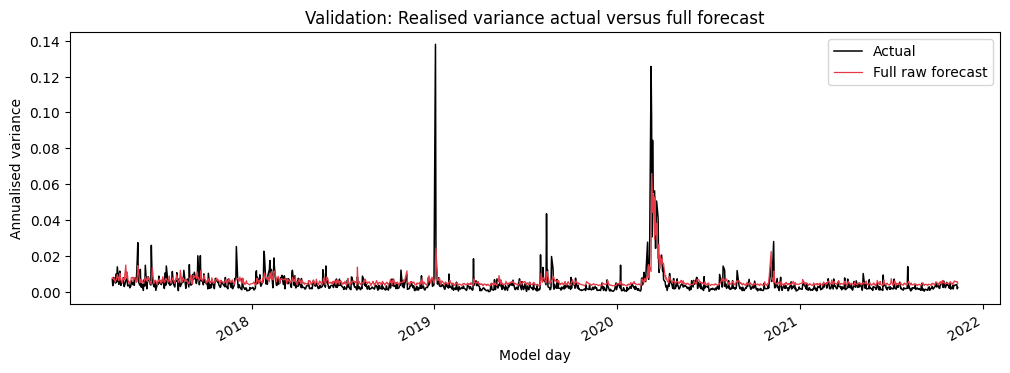

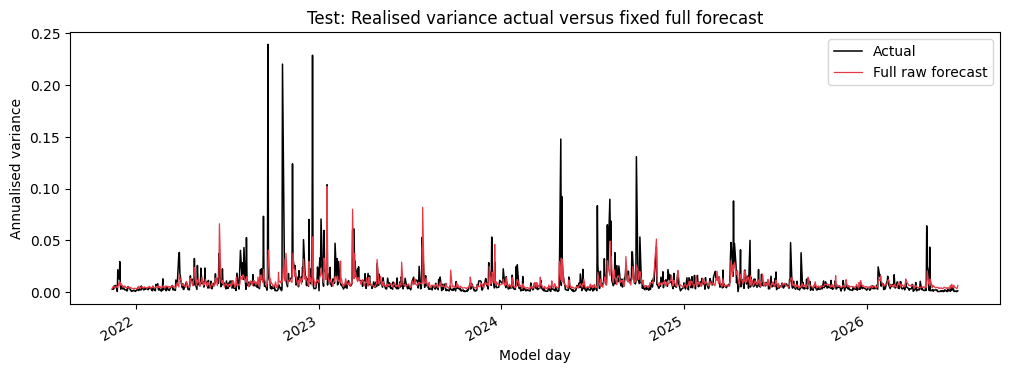

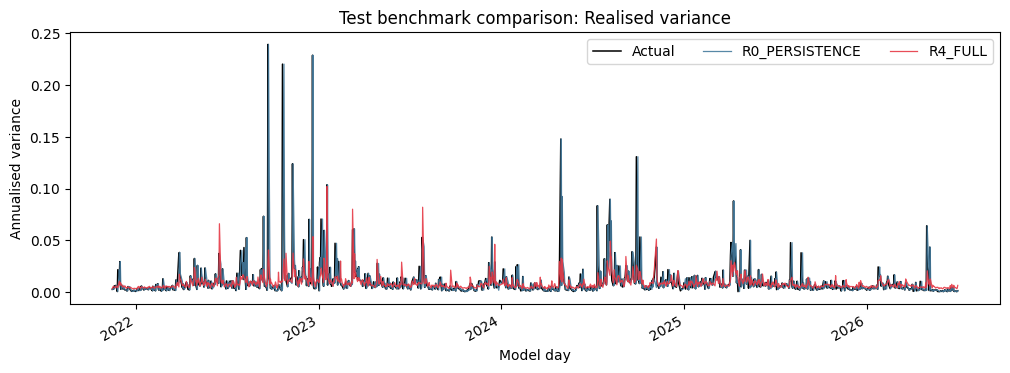

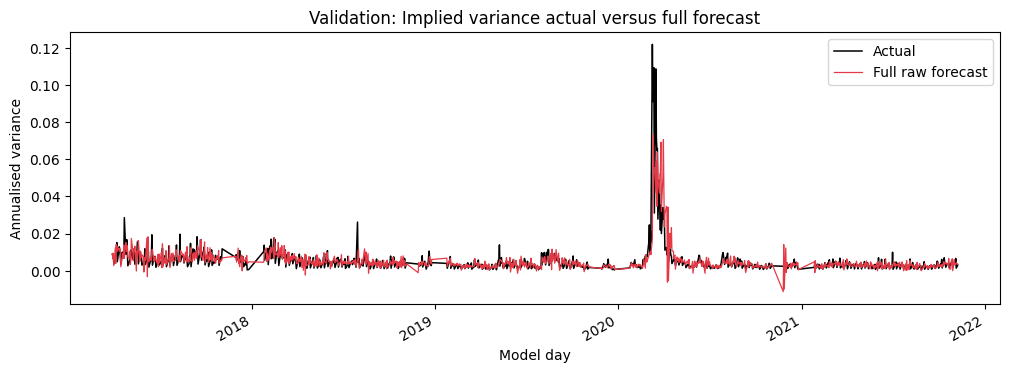

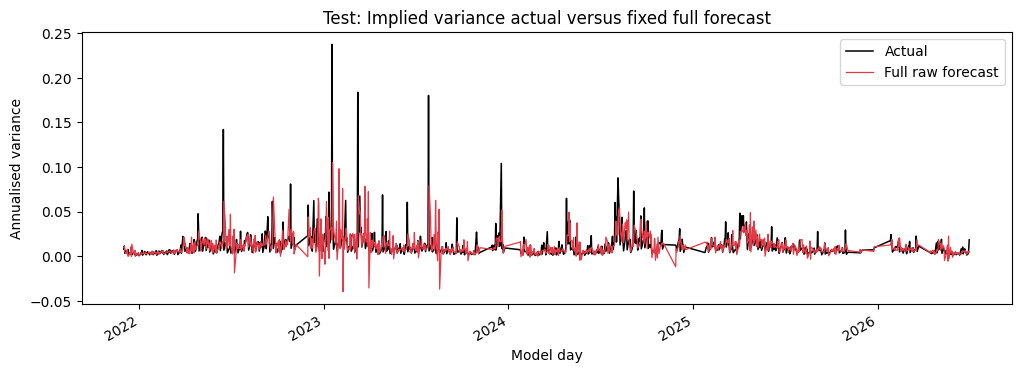

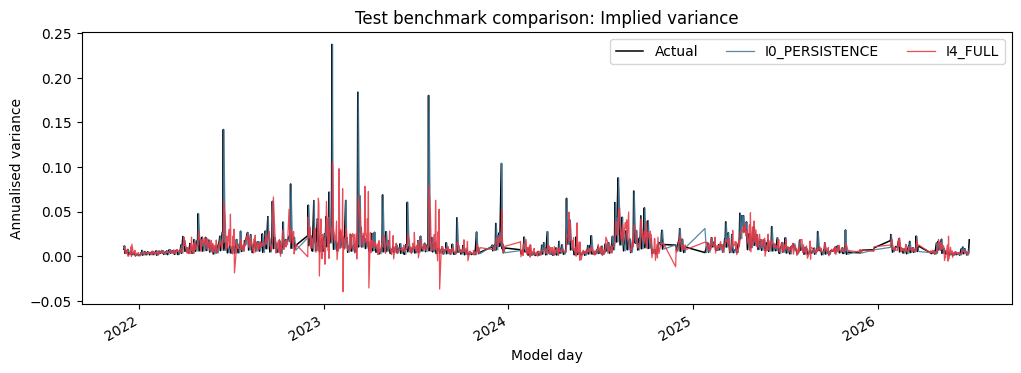

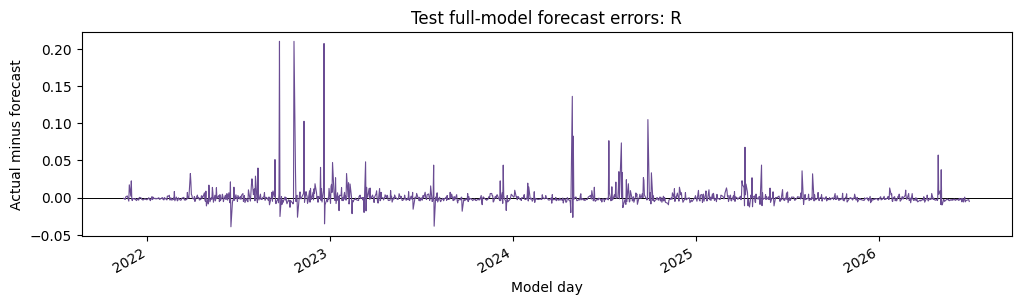

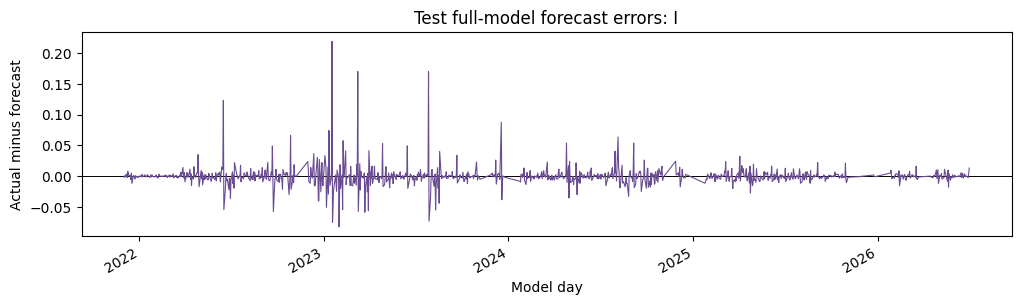

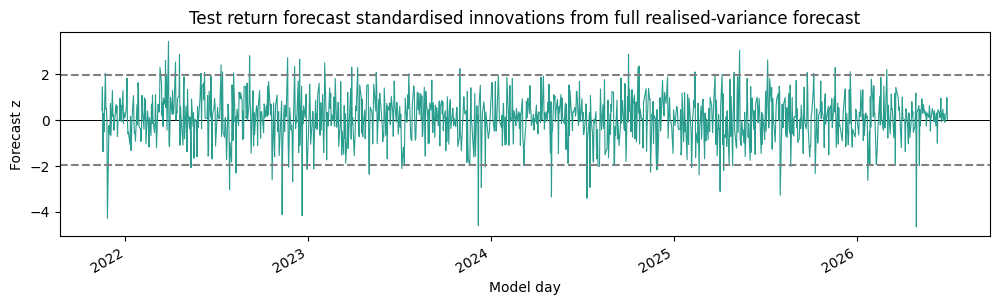

In [8]:
def plot_target_split(target, split, title):
    show = test_forecasts.loc[(test_forecasts['target'].eq(target)) & (test_forecasts['sample_split'].eq(split)) & test_forecasts['model_name'].isin([f'{target}0_PERSISTENCE', f'{target}4_FULL'])].copy()
    if show.empty:
        show = validation_forecasts.loc[(validation_forecasts['target'].eq(target)) & (validation_forecasts['sample_split'].eq(split))].copy()
        prefix = 'R' if target == 'R' else 'I'
        show = show.loc[show['model_name'].isin([f'{prefix}0_PERSISTENCE', f'{prefix}4_FULL'])]
    pivot = show.pivot(index='model_day', columns='model_name', values='raw_forecast')
    actual = show.drop_duplicates('model_day').set_index('model_day')['actual']
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(actual.index, actual, label='Actual', color='black', linewidth=1.1)
    for col, color in zip(pivot.columns, ['#457b9d', '#e63946']):
        ax.plot(pivot.index, pivot[col], label=col, color=color, linewidth=0.9, alpha=0.9)
    ax.set_title(title); ax.set_xlabel('Model day'); ax.set_ylabel('Annualised variance'); ax.legend(ncol=3)
    fig.autofmt_xdate(); plt.show()

for target, label in [('R', 'Realised variance'), ('I', 'Implied variance')]:
    prefix = 'R' if target == 'R' else 'I'
    valid = validation_forecasts.loc[(validation_forecasts['target'].eq(target)) & validation_forecasts['model_name'].eq(f'{prefix}4_FULL')]
    test = test_forecasts.loc[(test_forecasts['target'].eq(target)) & test_forecasts['model_name'].eq(f'{prefix}4_FULL')]
    for frame, title in [(valid, f'Validation: {label} actual versus full forecast'), (test, f'Test: {label} actual versus fixed full forecast')]:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(frame['model_day'], frame['actual'], label='Actual', color='black', linewidth=1.1)
        ax.plot(frame['model_day'], frame['raw_forecast'], label='Full raw forecast', color='#e63946', linewidth=0.9)
        ax.set_title(title); ax.set_xlabel('Model day'); ax.set_ylabel('Annualised variance'); ax.legend()
        fig.autofmt_xdate(); plt.show()
    plot_target_split(target, 'test', f'Test benchmark comparison: {label}')

for target, prefix in [('R', 'R'), ('I', 'I')]:
    frame = test_forecasts.loc[(test_forecasts['target'].eq(target)) & test_forecasts['model_name'].eq(f'{prefix}4_FULL')]
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axhline(0, color='black', linewidth=.7)
    ax.plot(frame['model_day'], frame['forecast_error'], color='#6a4c93', linewidth=.8)
    ax.set_title(f'Test full-model forecast errors: {target}'); ax.set_xlabel('Model day'); ax.set_ylabel('Actual minus forecast')
    fig.autofmt_xdate(); plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
test_z = return_forecasts.loc[return_forecasts['sample_split'].eq('test')]
ax.axhline(0, color='black', linewidth=.7); ax.plot(test_z['model_day'], test_z['z_forecast'], color='#2a9d8f', linewidth=.8)
ax.axhline(1.96, color='grey', linestyle='--'); ax.axhline(-1.96, color='grey', linestyle='--')
ax.set_title('Test return forecast standardised innovations from full realised-variance forecast')
ax.set_xlabel('Model day'); ax.set_ylabel('Forecast z'); fig.autofmt_xdate(); plt.show()

## 9. Tidy outputs and final Exercise 2 conclusion

Forecast comparisons are descriptive out-of-sample evidence. Granger-causal dependence and TDMI support do not automatically imply economic forecast improvement. The exact Bloomberg snapshot/fixing time remains unresolved, so results are one-model-day-ahead forecasts based on the previous indexed implied-volatility observation, not executable forecasts at an asserted intraday fixing time.

In [9]:
coefficient_exports = pd.concat([train_coefficients, final_coefficients], ignore_index=True)
forecast_error_diagnostics = (all_forecasts.groupby(['forecast_scheme','sample_split','target','model_name'], as_index=False)
    .agg(error_mean=('forecast_error','mean'), error_sd=('forecast_error','std'),
         error_skewness=('forecast_error', lambda x: stats.skew(x, bias=False)),
         error_excess_kurtosis=('forecast_error', lambda x: stats.kurtosis(x, fisher=True, bias=False))))
full_final_coefficients = final_coefficients.loc[final_coefficients['model_name'].isin(['R4_FULL', 'I4_FULL'])].copy()
background_specification = full_final_coefficients.assign(
    n=1, m=16, annualisation='R=252*rv_within; I=iv_ann_var=(q/100)^2',
    forecast_horizon='one_model_day_ahead', event_aware=False, eventless=False,
    equation5_implemented=False, upstream_notebook16_run_id=model_spec['RUN_ID'].iloc[0],
)
background_specification = background_specification.merge(
    innovation_scales[['model_name','residual_innovation_sd','scale_under_delta_t_1_over_252']],
    on='model_name', how='left'
)

exports = {
    '17_model_coefficients.csv': coefficient_exports,
    '17_innovation_scales.csv': innovation_scales,
    '17_validation_forecasts.csv': validation_forecasts,
    '17_validation_metrics.csv': validation_metrics,
    '17_test_forecasts.csv': pd.concat([test_forecasts, expanding_forecasts], ignore_index=True),
    '17_test_metrics.csv': pd.concat([test_metrics, expanding_metrics], ignore_index=True),
    '17_nonpositive_forecast_audit.csv': nonpositive_audit,
    '17_return_distribution_diagnostics.csv': return_diagnostics,
    '17_forecast_error_diagnostics.csv': forecast_error_diagnostics,
    '17_subperiod_performance.csv': subperiod_performance,
    '17_final_background_specification.csv': background_specification,
}
for name, frame in exports.items():
    frame = frame.copy()
    frame.insert(0, 'RUN_ID', RUN_ID)
    frame.to_csv(PROCESSED / name, index=False)
    exports[name] = frame
    check = pd.read_csv(PROCESSED / name)
    assert len(check) == len(frame) and check['RUN_ID'].nunique() == 1 and check['RUN_ID'].iloc[0] == RUN_ID

primary = test_metrics.loc[test_metrics['forecast_scheme'].eq('fixed_train_validation')].copy()
r_metrics = primary.loc[primary['model_name'].eq('R4_FULL')].iloc[0]
i_metrics = primary.loc[primary['model_name'].eq('I4_FULL')].iloc[0]
r3_metrics = primary.loc[primary['model_name'].eq('R3_AR_I')].iloc[0]
best_r = primary.loc[primary['target'].eq('R')].sort_values('RMSE').iloc[0]['model_name']
best_i = primary.loc[primary['target'].eq('I')].sort_values('RMSE').iloc[0]['model_name']
expand_full = expanding_metrics.loc[expanding_metrics['model_name'].isin(['R4_FULL','I4_FULL'])].set_index('model_name')
return_test = return_diagnostics.loc[(return_diagnostics['forecast_scheme'].eq('fixed_train_validation')) & return_diagnostics['sample_split'].eq('test')]
summary = {
    'exercise_2_status': 'PASS',
    'realised_full_calibration_n': int(len(final_fits['R4_FULL']['sample'])),
    'implied_full_calibration_n': int(len(final_fits['I4_FULL']['sample'])),
    'n': 1, 'm': 16,
    'realised_full_test_MAE': float(r_metrics['MAE']), 'realised_full_test_RMSE': float(r_metrics['RMSE']),
    'realised_full_test_QLIKE': float(r_metrics['QLIKE']), 'realised_full_test_OOS_R2': float(r_metrics['OOS_R2_vs_persistence']),
    'implied_full_test_MAE': float(i_metrics['MAE']), 'implied_full_test_RMSE': float(i_metrics['RMSE']),
    'implied_full_test_QLIKE': float(i_metrics['QLIKE']), 'implied_full_test_OOS_R2': float(i_metrics['OOS_R2_vs_persistence']),
    'best_realised_benchmark_test': best_r, 'best_implied_benchmark_test': best_i,
    'AR_I_beats_R_persistence_RMSE': bool(r3_metrics['RMSE'] < primary.loc[primary['model_name'].eq('R0_PERSISTENCE'),'RMSE'].iloc[0]),
    'FULL_R_beats_R_persistence_RMSE': bool(r_metrics['RMSE'] < primary.loc[primary['model_name'].eq('R0_PERSISTENCE'),'RMSE'].iloc[0]),
    'FULL_I_beats_I_persistence_RMSE': bool(i_metrics['RMSE'] < primary.loc[primary['model_name'].eq('I0_PERSISTENCE'),'RMSE'].iloc[0]),
    'nonpositive_R_full_test': int(r_metrics['nonpositive_count']), 'nonpositive_I_full_test': int(i_metrics['nonpositive_count']),
    'return_test_mean_NLL': float(return_test['mean_NLL'].iloc[0]),
    'return_test_68_coverage': float(return_test.loc[np.isclose(return_test['interval_nominal_coverage'], .68),'interval_empirical_coverage'].iloc[0]),
    'return_test_95_coverage': float(return_test.loc[np.isclose(return_test['interval_nominal_coverage'], .95),'interval_empirical_coverage'].iloc[0]),
    'expanding_window_full_R_RMSE': float(expand_full.loc['R4_FULL','RMSE']),
    'expanding_window_full_I_RMSE': float(expand_full.loc['I4_FULL','RMSE']),
    'event_unaware': True, 'eventless': False, 'ready_for_exercise_3': True,
}
display(Markdown('## Exercise 2 machine-readable summary'))
print(pd.Series(summary).to_json(indent=2))
print('Interpretation: this is an event-unaware parametric background; event dates remain in the data. Exercise 3 has not been started.')

## Exercise 2 machine-readable summary

{
  "exercise_2_status":"PASS",
  "realised_full_calibration_n":4186,
  "implied_full_calibration_n":3154,
  "n":1,
  "m":16,
  "realised_full_test_MAE":0.0055461356,
  "realised_full_test_RMSE":0.0149888031,
  "realised_full_test_QLIKE":-3.8598018399,
  "realised_full_test_OOS_R2":0.5020212926,
  "implied_full_test_MAE":0.0077998334,
  "implied_full_test_RMSE":0.0167764325,
  "implied_full_test_QLIKE":308441781.1972620487,
  "implied_full_test_OOS_R2":0.2585474424,
  "best_realised_benchmark_test":"R4_FULL",
  "best_implied_benchmark_test":"I1_AR16",
  "AR_I_beats_R_persistence_RMSE":true,
  "FULL_R_beats_R_persistence_RMSE":true,
  "FULL_I_beats_I_persistence_RMSE":true,
  "nonpositive_R_full_test":0,
  "nonpositive_I_full_test":36,
  "return_test_mean_NLL":-3.7546176209,
  "return_test_68_coverage":0.6895093063,
  "return_test_95_coverage":0.9390862944,
  "expanding_window_full_R_RMSE":0.0149894597,
  "expanding_window_full_I_RMSE":0.0163136641,
  "event_unaware":true,
  "eventless"

## 10. Interpretation and handoff

The coefficient tables report the calibrated frozen equations; the benchmark metrics answer whether their dependence structure yields out-of-sample forecasting value. A positive OOS \(R^2\) means a model improves squared-error performance against persistence on the identical target dates. Non-positive raw variance forecasts, if present, are not hidden: MAE/RMSE use them raw, while QLIKE and Equation (1) use only the fixed numerical floor where positivity is mathematically required.

The background remains event-unaware. The precise Bloomberg daily fixing/snapshot time is unresolved, so no timestamp-level executable fixing claim is made. The exported final background specification is explicitly marked event_aware=False and eventless=False for the later Exercise 3 workflow.

## 11. Explicit Exercise 2 answers

The following final read-out separates dependence from forecast value. It reports the observed-\(R_t\) in-sample Equation (1) diagnostic separately from the ex-ante return forecast distribution, which uses the prior-day full realised-variance forecast.

In [10]:
observed_return_sample = panel.loc[
    panel['sample_split'].isin(['train', 'validation']) & np.isfinite(panel[['r', 'R']]).all(axis=1),
    ['model_day', 'r', 'R'],
].copy()
observed_return_sample['z_observed_R'] = (observed_return_sample['r'] - mu_final) / np.sqrt(observed_return_sample['R'] / 252.0)
observed_z_summary = pd.Series({
    'n': len(observed_return_sample),
    'mean': observed_return_sample['z_observed_R'].mean(),
    'std': observed_return_sample['z_observed_R'].std(ddof=1),
    'excess_kurtosis': stats.kurtosis(observed_return_sample['z_observed_R'], fisher=True, bias=False),
})
print('Observed-R in-sample Equation (1) diagnostic (not a forecast):')
print(observed_z_summary.to_string())

r0 = primary.loc[primary['model_name'].eq('R0_PERSISTENCE')].iloc[0]
i0 = primary.loc[primary['model_name'].eq('I0_PERSISTENCE')].iloc[0]
i1 = primary.loc[primary['model_name'].eq('I1_AR16')].iloc[0]
full_i_nonpositive = int(i_metrics['nonpositive_count'])
display(Markdown(f"""## Final Exercise 2 interpretation

1. **Realised equation calibration.** The final full realised equation has intercept {final_coefficients.query("model_name == 'R4_FULL' and coefficient == 'const'").estimate.iloc[0]:.6f}, \(Q_{{t-1}}\) coefficient {final_coefficients.query("model_name == 'R4_FULL' and coefficient == 'Q_lag1'").estimate.iloc[0]:.4f}, \(R_{{t-1}}\) coefficient {final_coefficients.query("model_name == 'R4_FULL' and coefficient == 'R_lag1'").estimate.iloc[0]:.4f}, and \(I_{{t-1}}\) coefficient {final_coefficients.query("model_name == 'R4_FULL' and coefficient == 'I_lag1'").estimate.iloc[0]:.4f}. Realised variance has modest own-lag persistence, while lagged implied variance is the dominant conditional coefficient.

2. **Implied equation calibration.** Implied variance shows substantial distributed persistence: the leading \(I\)-lag coefficients are reported in the grouped coefficient table, including \(I_{{t-1}}={final_coefficients.query("model_name == 'I4_FULL' and coefficient == 'I_lag1'").estimate.iloc[0]:.4f}\) and \(I_{{t-10}}={final_coefficients.query("model_name == 'I4_FULL' and coefficient == 'I_lag10'").estimate.iloc[0]:.4f}\). The complete 16-lag \(Q/R/I\) structure is retained because it is frozen upstream, not because of individual p-values.

3. **Out-of-sample realised forecasting.** The AR-plus-implied benchmark improves test RMSE from {r0.RMSE:.5f} for persistence to {r3_metrics.RMSE:.5f}; the full model is marginally lower at {r_metrics.RMSE:.5f} and has OOS \(R^2={r_metrics.OOS_R2_vs_persistence:.3f}\). Thus the strong \(I_{{t-1}}\rightarrow R_t\) dependence has substantial test-period forecasting value; the incremental \(Q\) contribution beyond AR-plus-implied variance is small in RMSE terms.

4. **Out-of-sample implied forecasting.** The full model beats raw persistence (test RMSE {i_metrics.RMSE:.5f} versus {i0.RMSE:.5f}; OOS \(R^2={i_metrics.OOS_R2_vs_persistence:.3f}) but does not beat the implied-only AR16 benchmark (RMSE {i1.RMSE:.5f}). Thus lagged \(Q\) and \(R\) add no test-RMSE improvement beyond the long implied-variance history in this fixed specification.

5. **Gaussian return forecast.** The ex-ante full-\(R\) return distribution has test mean forecast \(z={return_test.mean_z.iloc[0]:.3f}\), standard deviation {return_test.std_z.iloc[0]:.3f}, mean NLL {return_test.mean_NLL.iloc[0]:.3f}, and empirical 68%/95% coverage {summary['return_test_68_coverage']:.3f}/{summary['return_test_95_coverage']:.3f}. Excess kurtosis remains a distributional qualification, not a reason to discard the variance forecast.

6. **Stability and limitations.** Expanding-window full-model RMSE is {expand_full.loc['R4_FULL','RMSE']:.5f} for realised variance and {expand_full.loc['I4_FULL','RMSE']:.5f} for implied variance. No realised full-model test forecast is non-positive, whereas {full_i_nonpositive}/{int(i_metrics.n_forecasts)} ({full_i_nonpositive/int(i_metrics.n_forecasts):.1%}) full implied forecasts are non-positive; their raw values are retained and the fixed floor is used only for positivity-required scores. The exact Bloomberg daily fixing time remains unresolved, so these are indexed one-model-day-ahead forecasts, not timestamp-level executable fixing forecasts.

The ordinary background is event-unaware, not eventless. The required calculations and integrity checks passed, so the exported background is ready to freeze before Exercise 3; Notebook 18 has not been started."""))

Observed-R in-sample Equation (1) diagnostic (not a forecast):
n                  4567.000000
mean                  0.028523
std                   0.954265
excess_kurtosis      -0.442679


<>:33: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:33: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:33: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:33: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:33: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:33: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:35: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences wil

## Final Exercise 2 interpretation

1. **Realised equation calibration.** The final full realised equation has intercept 0.002489, \(Q_{t-1}\) coefficient 9.5777, \(R_{t-1}\) coefficient 0.0873, and \(I_{t-1}\) coefficient 0.4139. Realised variance has modest own-lag persistence, while lagged implied variance is the dominant conditional coefficient.

2. **Implied equation calibration.** Implied variance shows substantial distributed persistence: the leading \(I\)-lag coefficients are reported in the grouped coefficient table, including \(I_{t-1}=0.3585\) and \(I_{t-10}=0.3434\). The complete 16-lag \(Q/R/I\) structure is retained because it is frozen upstream, not because of individual p-values.

3. **Out-of-sample realised forecasting.** The AR-plus-implied benchmark improves test RMSE from 0.02124 for persistence to 0.01501; the full model is marginally lower at 0.01499 and has OOS \(R^2=0.502\). Thus the strong \(I_{t-1}ightarrow R_t\) dependence has substantial test-period forecasting value; the incremental \(Q\) contribution beyond AR-plus-implied variance is small in RMSE terms.

4. **Out-of-sample implied forecasting.** The full model beats raw persistence (test RMSE 0.01678 versus 0.01948; OOS \(R^2=0.259) but does not beat the implied-only AR16 benchmark (RMSE 0.01538). Thus lagged \(Q\) and \(R\) add no test-RMSE improvement beyond the long implied-variance history in this fixed specification.

5. **Gaussian return forecast.** The ex-ante full-\(R\) return distribution has test mean forecast \(z=0.071\), standard deviation 1.039, mean NLL -3.755, and empirical 68%/95% coverage 0.690/0.939. Excess kurtosis remains a distributional qualification, not a reason to discard the variance forecast.

6. **Stability and limitations.** Expanding-window full-model RMSE is 0.01499 for realised variance and 0.01631 for implied variance. No realised full-model test forecast is non-positive, whereas 36/1031 (3.5%) full implied forecasts are non-positive; their raw values are retained and the fixed floor is used only for positivity-required scores. The exact Bloomberg daily fixing time remains unresolved, so these are indexed one-model-day-ahead forecasts, not timestamp-level executable fixing forecasts.

The ordinary background is event-unaware, not eventless. The required calculations and integrity checks passed, so the exported background is ready to freeze before Exercise 3; Notebook 18 has not been started.